
# Triadic Cell Notebook v14
## Continuity threshold: minimum persistent state for emergent self-consistency

This notebook tests the design question:

> what is the minimum persistent state the system must carry before continuity actually emerges?

The hypothesis is:

- a disconnected system behaves like isolated prompts
- a connected system behaves like one continuing existence
- continuity is not magic; it should appear when enough state survives between episodes

## The experiment

We keep the same triadic memory substrate family, but vary **what survives** between episodes:

1. **none**
   - reset everything every episode

2. **bank only**
   - persistent memory slots survive
   - latent/coherence/readout reset

3. **bank + latent**
   - memory slots + internal register survive

4. **bank + latent + coherence**
   - memory slots + register + held-togetherness survive

5. **full state**
   - bank + latent + coherence + readout survive

Each variant runs across repeated episodes of:
- supervised storage
- partial-cue recall
- trust-gated acceptance

The target is not just raw accuracy.
The target is **continuity**:
- does performance accumulate?
- does slot geometry stabilize?
- do accepted recalls get cleaner over time?
- does the system behave like one growing runtime?



## What "continuity" means here

A system has continuity if later episodes benefit from earlier ones without collapsing into noise.

We measure that with:

- **raw accuracy**
- **accepted-only accuracy**
- **coverage**
- **slot divergence**
- **margin**
- **continuity gain** = late accuracy - early accuracy
- **trust gain** = late accepted precision - early accepted precision

The aim is to find the smallest state package that crosses from:
- episodic behavior
to
- persistent behavior


In [1]:

from __future__ import annotations

from dataclasses import dataclass
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.


In [2]:

@dataclass
class AddressedTriadicState:
    coherence: float = 0.72
    latent: np.ndarray = None
    readout: np.ndarray = None

    def __post_init__(self):
        if self.latent is None:
            self.latent = np.array([0.20, 0.35, 0.50, 0.15], dtype=float)
        if self.readout is None:
            self.readout = np.zeros(2, dtype=float)

    def copy(self):
        return AddressedTriadicState(
            coherence=float(self.coherence),
            latent=self.latent.copy(),
            readout=self.readout.copy(),
        )


In [3]:

class KeyedMemoryBank:
    def __init__(self, width: int = 4, leak: float = 0.015):
        self.width = width
        self.leak = float(leak)

        self.keys = np.array([
            [1.0, 0.2, 0.0, 0.0],
            [0.0, 1.0, 0.2, 0.0],
            [0.2, 0.0, 1.0, 0.2],
            [0.0, 0.2, 0.0, 1.0],
        ], dtype=float)
        self.keys = self.keys / np.linalg.norm(self.keys, axis=1, keepdims=True)
        self.slots = np.zeros((4, width), dtype=float)

    @staticmethod
    def _softmax(x: np.ndarray, temp: float = 1.0) -> np.ndarray:
        z = (x - np.max(x)) / max(temp, 1e-8)
        e = np.exp(z)
        return e / np.sum(e)

    def address(self, query: np.ndarray, content_mix: float = 0.15) -> np.ndarray:
        q = query / (np.linalg.norm(query) + 1e-8)
        key_scores = self.keys @ q

        if np.any(self.slots > 0):
            slot_norms = np.linalg.norm(self.slots, axis=1, keepdims=True) + 1e-8
            slot_dirs = self.slots / slot_norms
            content_scores = slot_dirs @ q
        else:
            content_scores = np.zeros_like(key_scores)

        scores = (1.0 - content_mix) * key_scores + content_mix * content_scores
        return self._softmax(scores, temp=0.08)

    def read(self, weights: np.ndarray) -> np.ndarray:
        return weights @ self.slots

    def write(self, weights: np.ndarray, value: np.ndarray, strength: float, topk: int = 1):
        self.slots *= (1.0 - self.leak)

        idx = np.argsort(weights)[::-1][:topk]
        masked = np.zeros_like(weights)
        masked[idx] = weights[idx]
        if masked.sum() > 0:
            masked = masked / masked.sum()

        for i in range(self.slots.shape[0]):
            self.slots[i] = np.clip(self.slots[i] + strength * masked[i] * value, 0.0, 1.0)
        return masked.copy()

    def slot_energy(self) -> np.ndarray:
        return self.slots.mean(axis=1)

    def copy(self):
        return copy.deepcopy(self)


In [4]:

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def nearest_index_and_margin(vec: np.ndarray, library: np.ndarray):
    sims = np.array([cosine_similarity(vec, p) for p in library], dtype=float)
    order = np.argsort(sims)[::-1]
    best = int(order[0])
    top1 = float(sims[order[0]])
    top2 = float(sims[order[1]]) if len(order) > 1 else 0.0
    return best, top1, top1 - top2


In [5]:

class TriadicCellV14:
    def __init__(self, B: float = 1.0, T: float = 1.0, R: float = 1.0):
        self.B = float(B)
        self.T = float(T)
        self.R = float(R)

        self.W_readout = np.array([
            [1.0, 0.2, 0.0, -0.3],
            [0.0, 0.8, -0.4, 0.6],
        ], dtype=float)

        self.W_query = np.array([
            [1.0, 0.0, 0.3, 0.0],
            [0.0, 1.0, 0.0, 0.4],
            [0.3, 0.0, 1.0, 0.0],
            [0.0, 0.4, 0.0, 1.0],
        ], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def _query(self, latent: np.ndarray) -> np.ndarray:
        raw_query = self.W_query @ latent
        return raw_query / (np.linalg.norm(raw_query) + 1e-8)

    def probe(self, cue: np.ndarray, bank: KeyedMemoryBank):
        query = self._query(cue)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)
        return addr.copy(), recalled.copy()

    def step(
        self,
        s: AddressedTriadicState,
        drive_vec: np.ndarray,
        bank: KeyedMemoryBank,
        target_slot: int | None = None,
        template_pull: float = 0.35,
        templates: np.ndarray | None = None,
        novelty_threshold: float = 0.10,
    ):
        query = self._query(s.latent)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)

        load = np.linalg.norm(s.readout) + 0.2 * np.linalg.norm(recalled)
        coherence_restore = 0.05 * self.B * (0.84 - s.coherence)
        coherence_burn = 0.07 * self.T * (1.0 - self.B) + 0.008 * load
        coherence = float(np.clip(s.coherence + coherence_restore - coherence_burn, 0.0, 1.0))

        composite_target = 0.72 * drive_vec + 0.28 * recalled
        follow = 0.20 * self.B * self.T * coherence * (composite_target - s.latent)
        static_drag = 0.04 * (1.0 - self.T) * (s.latent - np.array([0.20, 0.35, 0.50, 0.15]))
        unsupported_loss = 0.14 * self.T * (1.0 - self.B) * s.latent
        latent = self._clip(s.latent + follow - static_drag - unsupported_loss)

        delta_vec = np.abs(latent - s.latent)

        support = self.B * self.T * self.R * coherence
        projected = self.W_readout @ delta_vec
        projected = np.maximum(projected, 0.0)

        shell_decay = (0.18 * (1.0 - self.T) + 0.12 * (1.0 - self.R)) * s.readout
        readout = self._clip(0.82 * s.readout + 2.25 * support * projected - shell_decay)

        base_write_strength = float(0.60 * support * readout.mean())
        novelty = max(0.0, 1.0 - cosine_similarity(recalled, drive_vec) - novelty_threshold)
        write_strength = base_write_strength * novelty

        if target_slot is not None:
            weights = np.zeros(4, dtype=float)
            weights[target_slot] = 1.0
        else:
            weights = addr

        write_value = latent.copy()
        if target_slot is not None and templates is not None and template_pull > 0.0:
            write_value = np.clip((1.0 - template_pull) * latent + template_pull * templates[target_slot], 0.0, 1.0)

        bank.write(weights, write_value, write_strength, topk=1 if target_slot is not None else 2)

        next_state = AddressedTriadicState(
            coherence=coherence,
            latent=latent,
            readout=readout,
        )
        return next_state


In [6]:

patterns = np.array([
    [1.00, 0.05, 0.05, 0.05],
    [0.05, 1.00, 0.05, 0.05],
    [0.05, 0.05, 1.00, 0.05],
    [0.05, 0.05, 0.05, 1.00],
], dtype=float)

def partial_cue(pattern: np.ndarray, mask_prob: float = 0.5, noise: float = 0.04) -> np.ndarray:
    cue = pattern.copy()
    mask = rng.random(pattern.shape[0]) < mask_prob
    cue[mask] = 0.0
    cue += rng.normal(0.0, noise, size=cue.shape[0])
    return np.clip(cue, 0.0, 1.0)


In [7]:

def apply_persistence_mode(mode: str, state: AddressedTriadicState, bank: KeyedMemoryBank):
    if mode == "none":
        return AddressedTriadicState(), KeyedMemoryBank(width=4, leak=bank.leak)
    if mode == "bank only":
        return AddressedTriadicState(), bank.copy()
    if mode == "bank + latent":
        s = AddressedTriadicState()
        s.latent = state.latent.copy()
        return s, bank.copy()
    if mode == "bank + latent + coherence":
        s = AddressedTriadicState()
        s.latent = state.latent.copy()
        s.coherence = float(state.coherence)
        return s, bank.copy()
    if mode == "full state":
        return state.copy(), bank.copy()
    raise ValueError(f"Unknown mode: {mode}")


In [8]:

def run_episode(model: TriadicCellV14, state: AddressedTriadicState, bank: KeyedMemoryBank, template_pull: float = 0.35):
    for slot_idx, p in enumerate(patterns):
        for _ in range(10):
            drive = np.clip(p + rng.normal(0.0, 0.03, size=p.shape[0]), 0.0, 1.0)
            state = model.step(
                state,
                drive,
                bank,
                target_slot=slot_idx,
                template_pull=template_pull,
                templates=patterns,
                novelty_threshold=0.10,
            )

    rows = []
    bank_templates = bank.slots.copy()
    energies = np.clip(bank.slot_energy(), 1e-8, None)

    for idx, p in enumerate(patterns):
        for _ in range(16):
            cue = partial_cue(p, mask_prob=0.5, noise=0.04)
            addr, recalled = model.probe(cue, bank)

            pred_raw = int(np.argmax(addr))
            pred_bank, sim_bank, margin_bank = nearest_index_and_margin(recalled, bank_templates)

            weighted_scores = np.array([
                cosine_similarity(recalled, t) * e for t, e in zip(bank_templates, energies)
            ], dtype=float)
            order = np.argsort(weighted_scores)[::-1]
            pred_weighted = int(order[0])
            weighted_top1 = float(weighted_scores[order[0]])
            weighted_top2 = float(weighted_scores[order[1]]) if len(order) > 1 else 0.0
            weighted_margin = weighted_top1 - weighted_top2

            rows.append({
                "target_slot": idx,
                "pred_raw": pred_raw,
                "pred_bank": pred_bank,
                "pred_weighted": pred_weighted,
                "sim_raw": cosine_similarity(recalled, p),
                "bank_margin": margin_bank,
                "weighted_margin": weighted_margin,
            })

    probe_df = pd.DataFrame(rows)
    return state, bank, probe_df


In [9]:

def summarize_episode(probe_df: pd.DataFrame, bank: KeyedMemoryBank, threshold: float = 0.02):
    raw_acc = float((probe_df["pred_raw"] == probe_df["target_slot"]).mean())
    bank_acc = float((probe_df["pred_bank"] == probe_df["target_slot"]).mean())
    weighted_acc = float((probe_df["pred_weighted"] == probe_df["target_slot"]).mean())

    accepted = probe_df[probe_df["weighted_margin"] >= threshold].copy()
    coverage = len(accepted) / len(probe_df)
    accepted_acc = float((accepted["pred_weighted"] == accepted["target_slot"]).mean()) if len(accepted) else np.nan

    return {
        "raw_accuracy": raw_acc,
        "bank_accuracy": bank_acc,
        "weighted_accuracy": weighted_acc,
        "coverage": coverage,
        "accepted_accuracy": accepted_acc,
        "mean_weighted_margin": float(probe_df["weighted_margin"].mean()),
        "slot_divergence": float(np.std(bank.slot_energy())),
        "mean_slot_energy": float(bank.slot_energy().mean()),
    }


In [10]:

def run_continuity_experiment(mode: str, episodes: int = 20, threshold: float = 0.02, template_pull: float = 0.35):
    model = TriadicCellV14()
    state = AddressedTriadicState()
    bank = KeyedMemoryBank(width=4, leak=0.015)

    rows = []

    for ep in range(episodes):
        state, bank, probe_df = run_episode(model, state, bank, template_pull=template_pull)
        summary = summarize_episode(probe_df, bank, threshold=threshold)
        summary["episode"] = ep
        summary["mode"] = mode
        rows.append(summary)

        state, bank = apply_persistence_mode(mode, state, bank)

    return pd.DataFrame(rows)

modes = ["none", "bank only", "bank + latent", "bank + latent + coherence", "full state"]
results = pd.concat([run_continuity_experiment(mode) for mode in modes], ignore_index=True)
results.head()


,raw_accuracy,bank_accuracy,weighted_accuracy,coverage,accepted_accuracy,mean_weighted_margin,slot_divergence,mean_slot_energy,episode,mode
0,0.640625,0.640625,0.546875,0.156250,0.600000,0.014172,0.023512,0.046466,0,none
1,0.578125,0.578125,0.484375,0.265625,0.588235,0.016382,0.023228,0.046488,1,none
2,0.546875,0.531250,0.500000,0.296875,0.421053,0.017649,0.021671,0.043940,2,none
3,0.671875,0.703125,0.546875,0.375000,0.583333,0.020059,0.022751,0.044323,3,none
4,0.625000,0.625000,0.500000,0.250000,0.625000,0.016160,0.022741,0.045587,4,none



## Episode trajectories


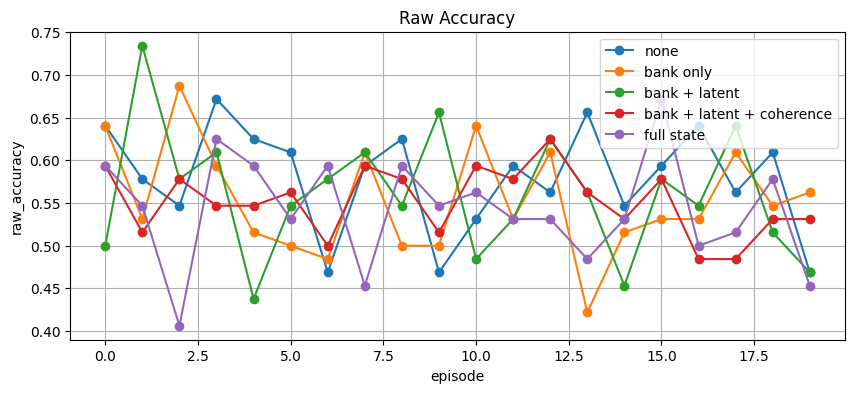

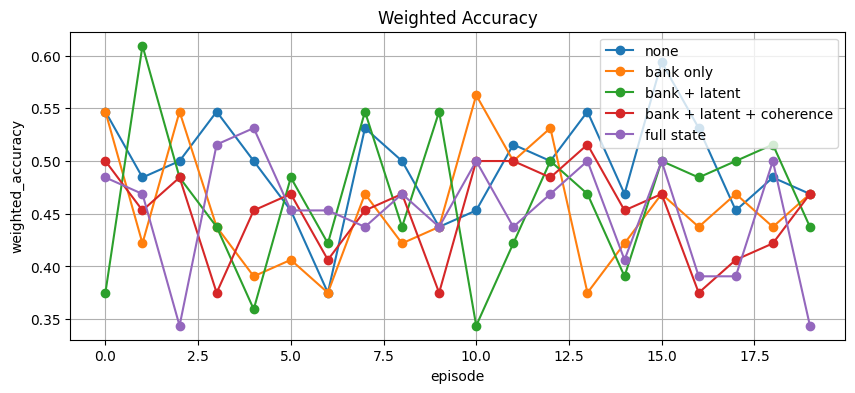

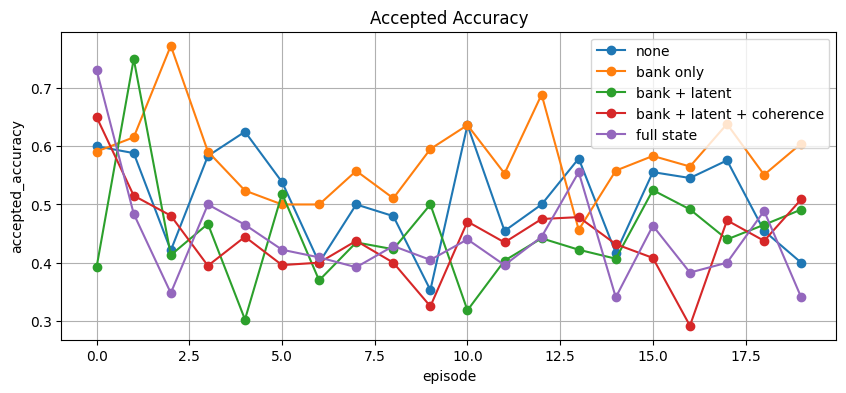

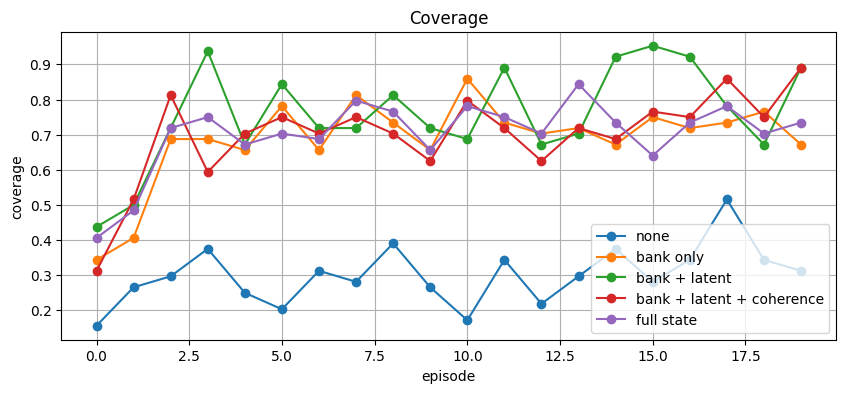

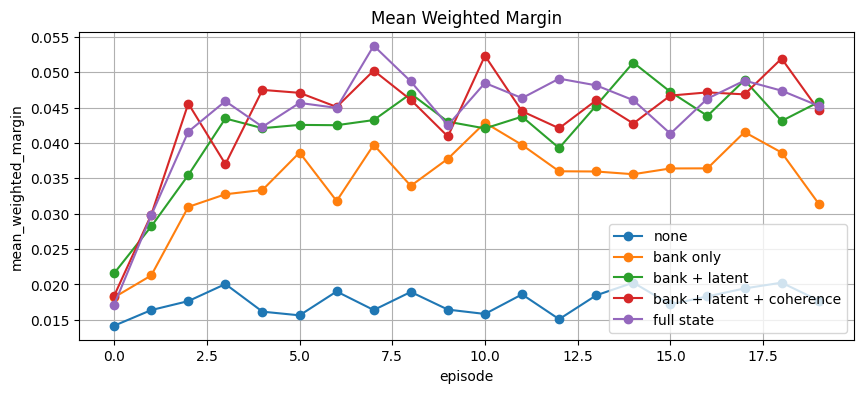

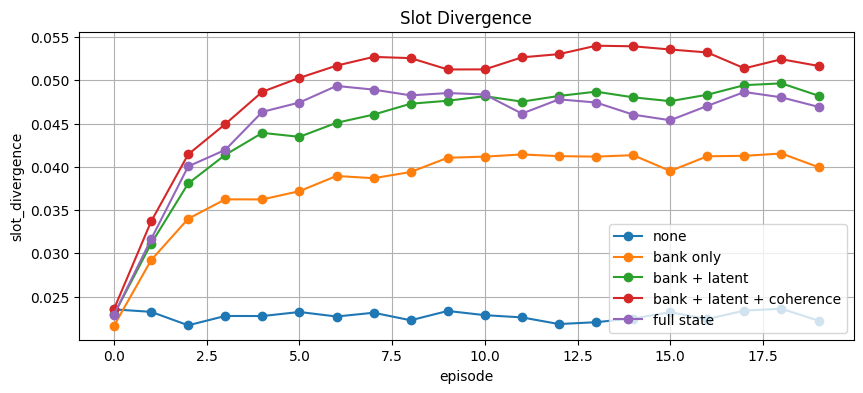

In [11]:

metrics = ["raw_accuracy", "weighted_accuracy", "accepted_accuracy", "coverage", "mean_weighted_margin", "slot_divergence"]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    for mode in modes:
        df = results[results["mode"] == mode]
        plt.plot(df["episode"], df[metric], marker="o", label=mode)
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("episode")
    plt.ylabel(metric)
    plt.legend(loc="best")
    plt.show()



## Continuity summary

Late-vs-early comparison gives a direct read on whether a mode accumulates useful state.


In [12]:

summary_rows = []

for mode in modes:
    df = results[results["mode"] == mode].reset_index(drop=True)

    early = df.iloc[:5]
    late = df.iloc[-5:]

    summary_rows.append({
        "mode": mode,
        "early_raw": float(early["raw_accuracy"].mean()),
        "late_raw": float(late["raw_accuracy"].mean()),
        "continuity_gain_raw": float(late["raw_accuracy"].mean() - early["raw_accuracy"].mean()),
        "early_accepted": float(early["accepted_accuracy"].mean()),
        "late_accepted": float(late["accepted_accuracy"].mean()),
        "trust_gain": float(late["accepted_accuracy"].mean() - early["accepted_accuracy"].mean()),
        "early_coverage": float(early["coverage"].mean()),
        "late_coverage": float(late["coverage"].mean()),
        "coverage_shift": float(late["coverage"].mean() - early["coverage"].mean()),
        "early_divergence": float(early["slot_divergence"].mean()),
        "late_divergence": float(late["slot_divergence"].mean()),
        "divergence_gain": float(late["slot_divergence"].mean() - early["slot_divergence"].mean()),
        "mean_margin": float(df["mean_weighted_margin"].mean()),
        "mean_raw_accuracy": float(df["raw_accuracy"].mean()),
        "mean_accepted_accuracy": float(df["accepted_accuracy"].mean()),
    })

continuity_df = pd.DataFrame(summary_rows).sort_values(
    ["trust_gain", "continuity_gain_raw", "divergence_gain"],
    ascending=False
)

continuity_df


,mode,early_raw,late_raw,continuity_gain_raw,early_accepted,late_accepted,trust_gain,early_coverage,late_coverage,coverage_shift,early_divergence,late_divergence,divergence_gain,mean_margin,mean_raw_accuracy,mean_accepted_accuracy
2,bank + latent,0.571875,0.550000,-0.021875,0.464979,0.482492,0.017513,0.653125,0.843750,0.190625,0.035484,0.048650,0.013166,0.041973,0.560156,0.448792
1,bank only,0.593750,0.556250,-0.037500,0.618748,0.588504,-0.030244,0.556250,0.728125,0.171875,0.031457,0.040701,0.009244,0.034642,0.553125,0.579647
0,none,0.612500,0.575000,-0.037500,0.563524,0.506263,-0.057262,0.268750,0.359375,0.090625,0.022780,0.022949,0.000168,0.017602,0.579688,0.510343
3,bank + latent + coherence,0.556250,0.521875,-0.034375,0.497020,0.423766,-0.073255,0.587500,0.803125,0.215625,0.038460,0.052459,0.013999,0.043626,0.551562,0.442636
4,full state,0.553125,0.543750,-0.009375,0.505517,0.415142,-0.090375,0.606250,0.718750,0.112500,0.036577,0.047210,0.010633,0.043960,0.542188,0.441818


In [13]:

def qualifies(row):
    return (
        row["continuity_gain_raw"] > 0 and
        row["trust_gain"] > 0 and
        row["divergence_gain"] > 0
    )

continuity_df["crosses_threshold"] = continuity_df.apply(qualifies, axis=1)
continuity_df


,mode,early_raw,late_raw,continuity_gain_raw,early_accepted,late_accepted,trust_gain,early_coverage,late_coverage,coverage_shift,early_divergence,late_divergence,divergence_gain,mean_margin,mean_raw_accuracy,mean_accepted_accuracy,crosses_threshold
2,bank + latent,0.571875,0.550000,-0.021875,0.464979,0.482492,0.017513,0.653125,0.843750,0.190625,0.035484,0.048650,0.013166,0.041973,0.560156,0.448792,False
1,bank only,0.593750,0.556250,-0.037500,0.618748,0.588504,-0.030244,0.556250,0.728125,0.171875,0.031457,0.040701,0.009244,0.034642,0.553125,0.579647,False
0,none,0.612500,0.575000,-0.037500,0.563524,0.506263,-0.057262,0.268750,0.359375,0.090625,0.022780,0.022949,0.000168,0.017602,0.579688,0.510343,False
3,bank + latent + coherence,0.556250,0.521875,-0.034375,0.497020,0.423766,-0.073255,0.587500,0.803125,0.215625,0.038460,0.052459,0.013999,0.043626,0.551562,0.442636,False
4,full state,0.553125,0.543750,-0.009375,0.505517,0.415142,-0.090375,0.606250,0.718750,0.112500,0.036577,0.047210,0.010633,0.043960,0.542188,0.441818,False



## Read the result

Look for the **first** mode where:
- late episodes are better than early episodes
- accepted-only precision improves, not just raw output
- slot divergence stabilizes upward

That is the minimum persistent state package that starts to behave like one enduring existence.

If only `full state` crosses, continuity needs everything.
If `bank + latent + coherence` crosses, readout may be epiphenomenal.
If `bank only` crosses, most of the continuity is already in memory geometry.
